## Выполнение домашней работы 3. KNN

## 1. Выбор датасета:

Ссылка на датасет: https://www.kaggle.com/datasets/uciml/iris

Краткая информация о нем: всего 4 признака, 3 класса растений

## 2. Первичный анализ данных

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("1. Загрузка данных")
df = pd.read_csv('sample_data/iris.csv')

1. Загрузка данных


In [2]:
df.size

900

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
df['Species'].value_counts(normalize=True)

Species
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
df.head(20)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


## 3. Подготовка данных

In [9]:
df = pd.get_dummies(df, columns=["Species"])
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_Iris-setosa,Species_Iris-versicolor,Species_Iris-virginica
0,1,5.1,3.5,1.4,0.2,True,False,False
1,2,4.9,3.0,1.4,0.2,True,False,False
2,3,4.7,3.2,1.3,0.2,True,False,False
3,4,4.6,3.1,1.5,0.2,True,False,False
4,5,5.0,3.6,1.4,0.2,True,False,False


Разделение на train/test:

In [10]:
from sklearn.model_selection import train_test_split
X = df.drop(["Species_Iris-setosa", "Species_Iris-versicolor", "Species_Iris-virginica"], axis=1)

y = df[["Species_Iris-virginica", "Species_Iris-virginica", "Species_Iris-virginica"]]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Так ну я проверил масштабируемость моего датасета ранее, и там не большие раличия поэтому для KNN это не будет большой проблемой. Однако это могло быть проблемой, потому что KNN оно сильно чувствительно к масштабу, то есть у параметра может быть больше число, но это не значит, что он важнее(может быть что наоборот) поэтому важно выдержать масштаб.


## 4. Обучение KNN


In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Модель и обучение модели

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy_score(y_test, y_pred)

1.0

Исследование параметров KNN

In [14]:
scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    scores.append(acc)

График как должно изменяться значение метрики в зависимости от k

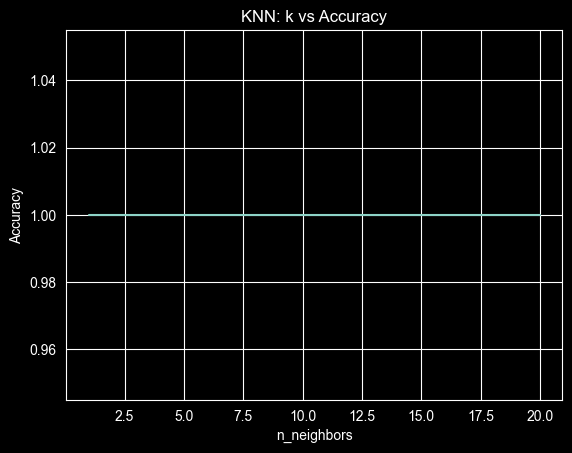

In [15]:
plt.plot(range(1,21), scores)
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.title("KNN: k vs Accuracy")
plt.show()

In [16]:
for w in ["uniform", "distance"]:
    knn = KNeighborsClassifier(n_neighbors=5, weights=w)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    print(w, accuracy_score(y_test, y_pred))

uniform 1.0
distance 1.0


In [17]:
metrics = ["euclidean", "manhattan", "minkowski"]

for m in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=m)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    print(m, accuracy_score(y_test, y_pred))

euclidean 1.0
manhattan 1.0
minkowski 1.0


Итоговая табличка результатов:

In [18]:
results = []

for k in [3,5,7]:
    for w in ["uniform", "distance"]:
        for m in ["euclidean", "manhattan"]:

            knn = KNeighborsClassifier(
                n_neighbors=k,
                weights=w,
                metric=m
            )

            knn.fit(X_train, y_train)
            y_pred = knn.predict(X_test)

            results.append({
                "k": k,
                "weights": w,
                "metric": m,
                "accuracy": accuracy_score(y_test, y_pred)
            })

import pandas as pd
results_df = pd.DataFrame(results)
results_df

,k,weights,metric,accuracy
0,3,uniform,euclidean,1.0
1,3,uniform,manhattan,1.0
2,3,distance,euclidean,1.0
3,3,distance,manhattan,1.0
4,5,uniform,euclidean,1.0
5,5,uniform,manhattan,1.0
6,5,distance,euclidean,1.0
7,5,distance,manhattan,1.0
8,7,uniform,euclidean,1.0
9,7,uniform,manhattan,1.0


Не ну, я не знаю как мне повезло так, я даже сам не верю что у меня идеально все.
Ну, а если приводить выводы по сделанной работе, то видно что у меня для k \in [2,21] метрики выдают 1. То есть одинаково, хотя должно было быть от 3 до 7, как я сам думал, чтобы брало здравое количество соседей. Так как при большом k точность будет уменьшаться, из-за того что будет больше соседей собственно, а для меньшего количества, наоборот булет меньше выборка.